# Testing with JAX framework
Better than pytorch (?)

In [48]:
#TODO: testare con la libreria diffrax

In [318]:
import diffrax as dfx
import equinox as eqx
import jax
import jax.numpy as jnp
import optax as opx
import matplotlib.pyplot as plt 
import jax.random as jr

jax.config.update("jax_enable_x64", True) # enable 64 float precision for stiff problems

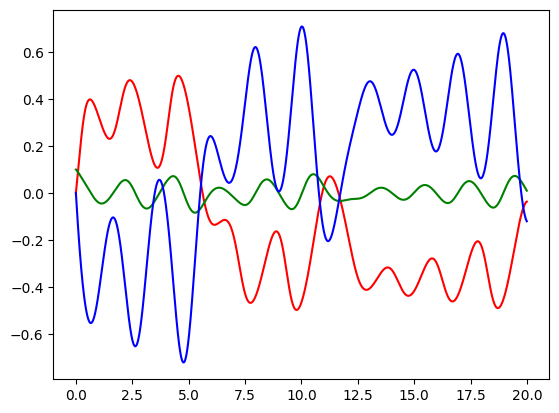

In [339]:
# generate train and val data
ALPHA, BETA, GAMMA, A, C = (10, 16, 0, 1, -0.143)

col_dict = {
    0: 'r', 
    1: 'g',
    2: 'b'
}
var_dict = {
    0: 'x',
    1: 'y',
    2: 'z'
}

def chua_model(t, xyz, args):
    alpha, beta, gamma, a, c = args 
    x,y,z = xyz 
    return jnp.array([
        alpha*(y-a*x**3-c*x),
        x-y+z, 
        -beta*y - gamma*z
    ])

T_MAX = 20

term = dfx.ODETerm(chua_model)
solver = dfx.Dopri5()
y0 = jnp.array((0.0001, 0.1, 0))
saveat = dfx.SaveAt(ts=jnp.arange(0, T_MAX, 0.01))

sol = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.1, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat)

plt.plot(sol.ts, sol.ys[:, 0], color='r')
plt.plot(sol.ts, sol.ys[:, 1], color='g')
plt.plot(sol.ts, sol.ys[:, 2], color='b')


In [345]:
T_MAX = 6
@jax.jit
def get_training_set(ALPHA, BETA, GAMMA, A, C):
    term = dfx.ODETerm(chua_model)
    solver = dfx.Dopri5()
    y0 = jnp.array((0.0001, 0.1, 0))
    saveat = dfx.SaveAt(ts=jnp.arange(0, T_MAX, 0.1))

    # training set
    sol = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.1, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat)

    x_train = sol.ys[::3]
    t_train = sol.ts[::3]

    # validation set
    saveat = dfx.SaveAt(ts=jnp.arange(0, T_MAX+4, 0.1))
    y0 = jnp.array((0.0001, 0.1, 0.0001))
    sol = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX+10, dt0=0.1, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat)

    x_val = sol.ys[::3]
    t_val = sol.ts[::3]

    return x_train, t_train, x_val, t_val 

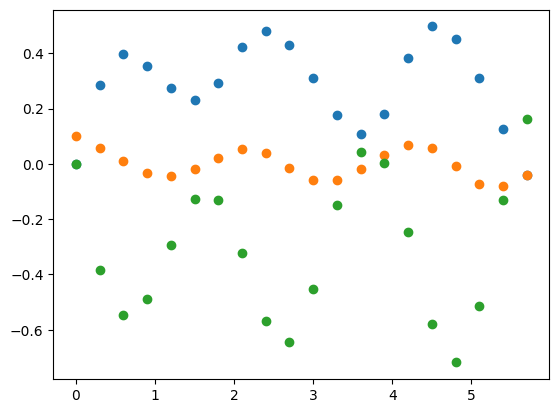

In [346]:
x_train, t_train, x_val, t_val = get_training_set(ALPHA, BETA, GAMMA, A, C)


plt.scatter(t_train, x_train[:, 0])
plt.scatter(t_train, x_train[:, 1])
plt.scatter(t_train, x_train[:, 2])


In [347]:
t_train.shape

(20,)

In [348]:
def zero_last_layer(mlp):
    last = mlp.layers[-1]

    new_last = eqx.tree_at(
        lambda l: (l.weight, l.bias),
        last,
        (
            jnp.zeros_like(last.weight),
            jnp.zeros_like(last.bias),
        ),
    )

    mlp = eqx.tree_at(lambda m: m.layers[-1], mlp, new_last)
    return mlp

In [349]:
class LinearInterpolator(eqx.Module):
    t_obs: jax.Array
    y_obs: jax.Array

    def __call__(self, t):
        t = jnp.clip(t, self.t_obs[0], self.t_obs[-1])
        idx = jnp.searchsorted(self.t_obs, t, side="left")
        idx = jnp.clip(idx, 1, self.t_obs.shape[0] - 1)

        t0, t1 = self.t_obs[idx - 1], self.t_obs[idx]
        y0, y1 = self.y_obs[idx - 1], self.y_obs[idx]
        w = (t - t0) / (t1 - t0 + 1e-12)
        return (1.0 - w) * y0 + w * y1

In [350]:
class ChuaUdeX_PEM(eqx.Module):
    net: eqx.nn.MLP
    alpha: float
    beta: float 
    gamma: float 
    K: jax.Array
    obs_fun: LinearInterpolator

    def __init__(self, alpha, beta, gamma, K, obs_fun, key):
        self.net = eqx.nn.MLP(
            in_size='scalar',
            out_size='scalar',
            width_size=128,
            depth=5,
            activation=jax.nn.relu,
            key=key,
        )
        
        self.alpha = alpha 
        self.beta = beta 
        self.gamma = gamma 
        self.K = jnp.asarray(K)
        self.obs_fun = obs_fun

        # zero weight the layer
        self.net = zero_last_layer(self.net)


    def physics(self, t, state):
        # known terms
        x, y, z = state
        return jnp.array(
            [self.alpha*y, x-y+z, -self.beta*y-self.gamma*z]
        )

    def residual(self, t, state):
        x, _, _ = state
        return jnp.array(
            [-self.alpha*self.net(x), 0,0]
        )
    
    def error(self, t, state):
        y_hat = self.obs_fun(t)
        return y_hat - state

    def __call__(self, t, state, args):
        return self.physics(t, state) + self.residual(t, state) + self.K * self.error(t, state)


In [351]:
class ChuaUdeX(eqx.Module):
    net: eqx.nn.MLP
    alpha: float
    beta: float 
    gamma: float 

    def __init__(self, alpha, beta, gamma, key):
        self.net = eqx.nn.MLP(
            in_size='scalar',
            out_size='scalar',
            width_size=128,
            depth=5,
            activation=jax.nn.relu,
            key=key,
        )
        
        self.alpha = alpha 
        self.beta = beta 
        self.gamma = gamma 

        # zero weight the layer
        self.net = zero_last_layer(self.net)


    def physics(self, t, state):
        # known terms
        x, y, z = state
        return jnp.array(
            [self.alpha*y, x-y+z, -self.beta*y-self.gamma*z]
        )

    def residual(self, t, state):
        x, _, _ = state
        return jnp.array(
            [-self.alpha*self.net(x), 0,0]
        )
    

    def __call__(self, t, state, args):
        return self.physics(t, state) + self.residual(t, state)


In [352]:
def solve_ude(model, y0, ts):
    term = dfx.ODETerm(model)
    solver = dfx.Kvaerno3()
    saveat = dfx.SaveAt(ts=ts)
    stepper = dfx.PIDController(rtol=1e-7, atol=1e-9)

    sol = dfx.diffeqsolve(
        term,
        solver,
        t0=ts[0],
        t1=ts[-1],
        dt0=ts[1] - ts[0],
        y0=y0,
        saveat=saveat,
        stepsize_controller=stepper
    )
    return sol.ys



In [353]:
def solve_ude_light(model, y0, ts):
    term = dfx.ODETerm(model)
    solver = dfx.Tsit5()
    saveat = dfx.SaveAt(ts=ts)
    stepper = dfx.PIDController(rtol=1e-7, atol=1e-9)

    sol = dfx.diffeqsolve(
        term,
        solver,
        t0=ts[0],
        t1=ts[-1],
        dt0=ts[1] - ts[0],
        y0=y0,
        saveat=saveat,
        stepsize_controller=stepper
    )
    return sol.ys



In [354]:
key = jr.PRNGKey(0)
ude = ChuaUdeX(ALPHA, BETA, GAMMA, key)

# Train Normal UDE
lr = 0.005
n_epochs = 1000
optimizer = opx.adam(lr)
opt_state = optimizer.init(eqx.filter(ude, eqx.is_inexact_array))

@eqx.filter_value_and_grad
def loss_fn(model, x0, y_true, ts):
    # calculate loss
    pred = solve_ude_light(model, x0, ts)
    return jnp.mean((pred - y_true) ** 2)

@eqx.filter_jit
def train_step(model, opt_state, x0, x_true, ts, optimizer):
    # one train step on the dataset
    loss, grads = loss_fn(model, x0, x_true, ts)
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

train_losses = []
val_losses = []

for i in range(0, n_epochs):
    # for the first 500 epochs only use 50% of the training dataset
    ude, opt_state, loss = train_step(ude, opt_state, x_train[0], x_train, t_train, optimizer)

    val_loss = loss_fn(ude, x_val[0], x_val, t_val)[0]

    print(f"{i}\t{loss:.4e}\t{val_loss:.4e}")

    train_losses.append(loss)
    val_losses.append(val_loss)

0	8.4337e-02	6.1953e+00
1	1.2781e+00	3.6308e-01
2	5.0617e-02	1.0232e-01
3	1.5603e-01	1.2470e-01
4	1.7864e-01	8.6597e-02
5	1.3399e-01	6.3011e-01
6	6.0263e-02	3.5198e-01
7	4.6965e-02	1.5620e-01
8	5.2146e-02	2.1900e-01
9	4.6902e-02	4.6823e-01
10	5.2992e-02	2.2807e-01
11	4.6499e-02	1.7551e-01
12	4.9718e-02	2.5686e-01
13	4.5874e-02	3.9316e-01
14	4.9568e-02	2.7501e-01
15	4.5853e-02	1.8924e-01
16	4.8376e-02	2.2172e-01
17	4.6547e-02	3.3731e-01
18	4.7278e-02	3.1908e-01
19	4.6716e-02	1.9400e-01
20	4.7897e-02	2.4353e-01
21	4.5941e-02	3.0351e-01
22	4.6318e-02	2.9069e-01
23	4.6063e-02	2.3845e-01
24	4.6025e-02	2.2979e-01
25	4.6215e-02	2.6858e-01
26	4.5818e-02	2.9766e-01
27	4.6212e-02	2.6677e-01
28	4.5807e-02	2.3463e-01
29	4.6064e-02	2.4360e-01
30	4.5903e-02	2.7812e-01
31	4.5898e-02	2.8347e-01
32	4.5973e-02	2.5273e-01
33	4.5807e-02	2.3774e-01
34	4.5976e-02	2.5575e-01
35	4.5789e-02	2.7931e-01
36	4.5920e-02	2.6974e-01
37	4.5821e-02	2.4601e-01
38	4.5846e-02	2.4444e-01
39	4.5861e-02	2.6458e-01
40	4.5790e

In [373]:
key = jr.PRNGKey(0)
linear_interp = LinearInterpolator(t_train, x_train)
linear_interp_jit = eqx.filter_jit(linear_interp)
ude_pem = ChuaUdeX_PEM(ALPHA, BETA, GAMMA, [0.3, 0.1, 0.1],linear_interp_jit, key)

# Train UDE PEM 

lr = 0.01
n_epochs = 1000
optimizer = opx.adam(lr)
opt_state = optimizer.init(eqx.filter(ude_pem, eqx.is_inexact_array))

train_losses_pem = []
val_losses_pem = []

for i in range(0, n_epochs):
    # for the first 500 epochs only use 50% of the training dataset
    ude_pem, opt_state, loss = train_step(ude_pem, opt_state, x_train[0], x_train, t_train, optimizer)

    val_loss = loss_fn(ude_pem, x_val[0], x_val, t_val)[0]

    print(f"{i}\t{loss:.4e}\t{val_loss:.4e}")

    train_losses_pem.append(loss)
    val_losses_pem.append(val_loss)

0	4.4442e-02	1.7732e+00
1	1.0393e+00	1.0236e-01
2	4.0515e-02	1.0579e-01
3	1.5848e-01	5.3229e-02
4	7.3370e-02	5.2081e-02
5	3.4042e-02	5.0132e+02
6	1.8271e+01	6.6081e-02
7	9.5154e-02	2.1935e-01
8	2.8387e-01	3.0964e-01
9	3.8156e-01	3.9415e-01
10	4.6831e-01	4.7572e-01
11	5.5137e-01	5.4740e-01
12	6.2439e-01	5.8494e-01
13	6.6526e-01	5.4902e-01
14	6.3882e-01	3.6716e-01
15	4.6232e-01	9.1966e-02
16	1.2852e-01	1.3800e+00
17	7.9413e-01	6.4085e-02
18	2.8059e-02	9.5181e-02
19	1.1335e-01	1.5716e-01
20	2.0251e-01	1.9485e-01
21	2.5266e-01	1.9735e-01
22	2.5413e-01	1.5764e-01
23	1.9466e-01	1.0591e-01
24	1.0407e-01	8.2048e-02
25	2.7138e-02	1.1635e-01
26	7.7663e-03	2.1172e-01
27	5.8126e-02	2.1593e-01
28	5.9587e-02	1.4989e-01
29	1.9175e-02	8.8783e-02
30	3.4026e-03	7.9608e-02
31	2.8310e-02	7.6978e-02
32	1.3809e-02	8.7849e-02
33	4.5958e-03	1.0766e-01
34	3.7418e-03	1.2888e-01
35	5.7712e-03	1.4764e-01
36	8.9529e-03	1.6049e-01
37	1.1668e-02	1.7006e-01
38	1.3940e-02	1.6594e-01
39	1.2813e-02	1.6016e-01
40	1.1487e

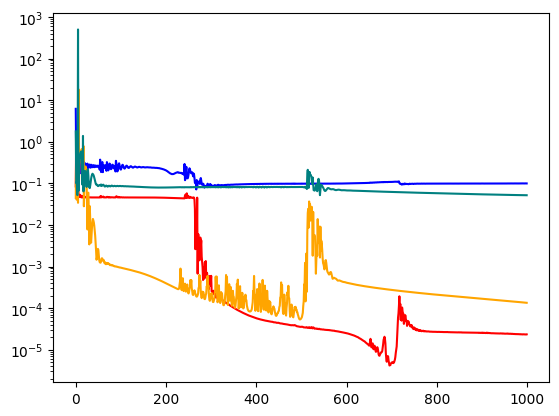

In [374]:
plt.semilogy(range(0, 1000), train_losses, color='r')
plt.semilogy(val_losses, color='b')

plt.semilogy(train_losses_pem, color='orange')
plt.semilogy(val_losses_pem, color='teal')

In [375]:
# save model
eqx.tree_serialise_leaves("./models_weights/31_3_ude_jax.eqx", ude)
eqx.tree_serialise_leaves("./models_weights/31_3_ude_pem_jax.eqx", ude_pem)


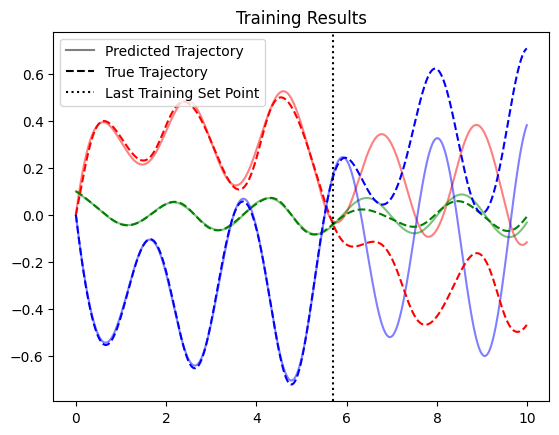

In [376]:
term = dfx.ODETerm(chua_model)
term_ude = dfx.ODETerm(ude_pem)

T_MAX = 10

solver = dfx.Tsit5()
y0 = x_train[0]
t_eval = jnp.arange(0, T_MAX, 0.01)
saveat = dfx.SaveAt(ts=t_eval)
stepper = dfx.PIDController(rtol=1e-7, atol=1e-9)

# training set
sol = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.1, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat, stepsize_controller=stepper)
traj_true = sol.ys

traj_final = dfx.diffeqsolve(term_ude, solver, t0=0, t1=T_MAX, dt0=0.1, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat, stepsize_controller=stepper).ys

plt.plot(t_eval, traj_final[:, 0], color='r', alpha=0.5)
plt.plot(t_eval, traj_final[:, 1], color='g', alpha=0.5)
plt.plot(t_eval, traj_final[:, 2], color='b', alpha=0.5)

plt.plot(t_eval, traj_true[:, 0], color='r', linestyle='--')
plt.plot(t_eval, traj_true[:, 1], color='g', linestyle='--')
plt.plot(t_eval, traj_true[:, 2], color='b', linestyle='--')

plt.plot([], [], color="k", alpha=0.5, label="Predicted Trajectory")
plt.plot([], [], color="k", linestyle="--", label="True Trajectory")
plt.axvline(t_train[-1], color="k", linestyle=":", label="Last Training Set Point")

plt.legend()
plt.title("Training Results")
plt.show()